# 07 - Automatic Differentiation, Backpropagation and Optimisers

**Advanced Machine Learning** | Haydar Kilic

Deep learning frameworks are, at their core, two ideas: a graph that records
every operation, and the chain rule applied to that graph in reverse.

For a composition $L = f_k \circ \dots \circ f_1$, forward mode propagates
derivatives with the Jacobians in order, costing one pass per *input*; reverse
mode propagates the adjoint
$\bar u = \sum_{v \in \text{children}(u)} \bar v\,\partial v/\partial u$
backwards, costing one pass per *output*. Since a loss has one scalar output and
millions of parameters, reverse mode is the right choice -- and it is
backpropagation.

The toolkit cell implements this in about 200 lines: every `Tensor` stores the
closure that pushes gradient to its parents.

In [1]:
# =========================================================================
# Toolkit for this lecture: the implementations used below, inlined so the
# notebook runs on its own (NumPy / SciPy / Matplotlib only).
# Read them alongside the derivations -- each block mirrors one formula.
# =========================================================================
from __future__ import annotations

import numpy as np

# --- datasets ------------------------------------------------------

def _rng(random_state: int | np.random.Generator | None) -> np.random.Generator:
    if isinstance(random_state, np.random.Generator):
        return random_state
    return np.random.default_rng(random_state)

def make_sine(n_samples=100, noise=0.2, x_range=(-3.0, 3.0), random_state=None):
    r"""1-D regression problem :math:`y = \sin(x) + \varepsilon`."""
    rng = _rng(random_state)
    X = rng.uniform(x_range[0], x_range[1], size=(n_samples, 1))
    y = np.sin(X[:, 0]) + noise * rng.standard_normal(n_samples)
    return X, y

def make_two_moons(n_samples=200, noise=0.2, random_state=None):
    """Two interleaving half circles -- the canonical non-linear 2-class toy."""
    rng = _rng(random_state)
    n_out = n_samples // 2
    n_in = n_samples - n_out
    t_out = np.linspace(0, np.pi, n_out)
    t_in = np.linspace(0, np.pi, n_in)
    outer = np.stack([np.cos(t_out), np.sin(t_out)], axis=1)
    inner = np.stack([1 - np.cos(t_in), 0.5 - np.sin(t_in)], axis=1)
    X = np.vstack([outer, inner]) + noise * rng.standard_normal((n_samples, 2))
    y = np.hstack([np.zeros(n_out, dtype=int), np.ones(n_in, dtype=int)])
    perm = rng.permutation(n_samples)
    return X[perm], y[perm]

def train_test_split(*arrays, test_size=0.25, random_state=None, stratify=None):
    """Shuffle-split arrays, optionally stratified by ``stratify`` labels."""
    if not arrays:
        raise ValueError("At least one array is required.")
    n = len(arrays[0])
    for arr in arrays:
        if len(arr) != n:
            raise ValueError("All arrays must share the same first dimension.")
    rng = _rng(random_state)

    if stratify is None:
        idx = rng.permutation(n)
        n_test = int(round(test_size * n))
        test_idx, train_idx = idx[:n_test], idx[n_test:]
    else:
        stratify = np.asarray(stratify)
        train_parts, test_parts = [], []
        for value in np.unique(stratify):
            group = np.flatnonzero(stratify == value)
            group = group[rng.permutation(len(group))]
            n_test = int(round(test_size * len(group)))
            test_parts.append(group[:n_test])
            train_parts.append(group[n_test:])
        train_idx = np.concatenate(train_parts)
        test_idx = np.concatenate(test_parts)
        train_idx = train_idx[rng.permutation(len(train_idx))]
        test_idx = test_idx[rng.permutation(len(test_idx))]

    out = []
    for arr in arrays:
        arr = np.asarray(arr)
        out.extend([arr[train_idx], arr[test_idx]])
    return tuple(out)

# --- metrics -------------------------------------------------------

_EPS = 1e-12

def accuracy(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.mean(y_true == y_pred))

def r2_score(y_true, y_pred):
    r"""Coefficient of determination :math:`1 - SS_{res}/SS_{tot}`."""
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return float(1.0 - ss_res / (ss_tot + _EPS))

# --- autodiff ------------------------------------------------------

def _unbroadcast(grad, shape):
    """Reduce ``grad`` back to ``shape`` after NumPy broadcasting."""
    while grad.ndim > len(shape):
        grad = grad.sum(axis=0)
    for axis, size in enumerate(shape):
        if size == 1 and grad.shape[axis] != 1:
            grad = grad.sum(axis=axis, keepdims=True)
    return grad.reshape(shape)

class Tensor:
    """A NumPy array plus a gradient and a backward closure."""

    __array_priority__ = 100  # make ndarray * Tensor dispatch here

    def __init__(self, data, requires_grad=True, _children=(), _op=""):
        self.data = np.asarray(data, dtype=float)
        self.grad = np.zeros_like(self.data)
        self.requires_grad = requires_grad
        self._backward = lambda: None
        self._prev = tuple(_children)
        self._op = _op

    # ------------------------------------------------------------- plumbing
    def __repr__(self):
        return f"Tensor(shape={self.data.shape}, op={self._op or 'leaf'!r})"

    @property
    def shape(self):
        return self.data.shape

    @staticmethod
    def _wrap(other):
        return other if isinstance(other, Tensor) else Tensor(other, requires_grad=False)

    def zero_grad(self):
        self.grad = np.zeros_like(self.data)

    # ----------------------------------------------------------- arithmetic
    def __add__(self, other):
        other = self._wrap(other)
        out = Tensor(self.data + other.data, _children=(self, other), _op="+")

        def _backward():
            self.grad += _unbroadcast(out.grad, self.data.shape)
            other.grad += _unbroadcast(out.grad, other.data.shape)

        out._backward = _backward
        return out

    def __mul__(self, other):
        other = self._wrap(other)
        out = Tensor(self.data * other.data, _children=(self, other), _op="*")

        def _backward():
            self.grad += _unbroadcast(out.grad * other.data, self.data.shape)
            other.grad += _unbroadcast(out.grad * self.data, other.data.shape)

        out._backward = _backward
        return out

    def __matmul__(self, other):
        other = self._wrap(other)
        out = Tensor(self.data @ other.data, _children=(self, other), _op="@")

        def _backward():
            self.grad += out.grad @ other.data.T
            other.grad += self.data.T @ out.grad

        out._backward = _backward
        return out

    def __pow__(self, power):
        if not isinstance(power, (int, float)):
            raise TypeError("Only scalar powers are supported.")
        out = Tensor(self.data**power, _children=(self,), _op=f"**{power}")

        def _backward():
            self.grad += out.grad * power * self.data ** (power - 1)

        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1.0

    def __sub__(self, other):
        return self + (-self._wrap(other))

    def __truediv__(self, other):
        return self * (self._wrap(other) ** -1.0)

    def __radd__(self, other):
        return self + other

    def __rmul__(self, other):
        return self * other

    def __rsub__(self, other):
        return self._wrap(other) + (-self)

    def __rmatmul__(self, other):
        return self._wrap(other) @ self

    # ------------------------------------------------------------ reductions
    def sum(self, axis=None, keepdims=False):
        out = Tensor(self.data.sum(axis=axis, keepdims=keepdims), _children=(self,), _op="sum")

        def _backward():
            grad = out.grad
            if axis is not None and not keepdims:
                grad = np.expand_dims(grad, axis)
            self.grad += np.broadcast_to(grad, self.data.shape).copy()

        out._backward = _backward
        return out

    def mean(self, axis=None, keepdims=False):
        n = self.data.size if axis is None else self.data.shape[axis]
        return self.sum(axis=axis, keepdims=keepdims) * (1.0 / n)

    # ----------------------------------------------------------- non-linear
    def relu(self):
        out = Tensor(np.maximum(self.data, 0.0), _children=(self,), _op="relu")

        def _backward():
            self.grad += out.grad * (self.data > 0)

        out._backward = _backward
        return out

    def tanh(self):
        t = np.tanh(self.data)
        out = Tensor(t, _children=(self,), _op="tanh")

        def _backward():
            self.grad += out.grad * (1.0 - t**2)

        out._backward = _backward
        return out

    def sigmoid(self):
        s = 1.0 / (1.0 + np.exp(-np.clip(self.data, -60, 60)))
        out = Tensor(s, _children=(self,), _op="sigmoid")

        def _backward():
            self.grad += out.grad * s * (1.0 - s)

        out._backward = _backward
        return out

    def exp(self):
        e = np.exp(self.data)
        out = Tensor(e, _children=(self,), _op="exp")

        def _backward():
            self.grad += out.grad * e

        out._backward = _backward
        return out

    def log(self):
        out = Tensor(np.log(self.data), _children=(self,), _op="log")

        def _backward():
            self.grad += out.grad / self.data

        out._backward = _backward
        return out

    def reshape(self, *shape):
        out = Tensor(self.data.reshape(*shape), _children=(self,), _op="reshape")

        def _backward():
            self.grad += out.grad.reshape(self.data.shape)

        out._backward = _backward
        return out

    # -------------------------------------------------------------- backward
    def backward(self):
        """Back-propagate from a scalar output."""
        if self.data.size != 1:
            raise RuntimeError("backward() is only defined for scalar outputs.")
        topo, visited = [], set()

        def build(node):
            if id(node) in visited:
                return
            visited.add(id(node))
            for child in node._prev:
                build(child)
            topo.append(node)

        build(self)
        self.grad = np.ones_like(self.data)
        for node in reversed(topo):
            node._backward()

def softmax_cross_entropy(logits, y_int):
    r"""Mean softmax cross-entropy; ``y_int`` holds integer class indices.

    Implemented in one node so the backward pass is the numerically stable
    :math:`(\mathrm{softmax}(z) - \mathrm{onehot}(y))/n`.
    """
    y_int = np.asarray(y_int, dtype=int)
    z = logits.data
    z_shift = z - z.max(axis=1, keepdims=True)
    log_probs = z_shift - np.log(np.exp(z_shift).sum(axis=1, keepdims=True))
    n = len(y_int)
    loss = -log_probs[np.arange(n), y_int].mean()
    out = Tensor(loss, _children=(logits,), _op="softmax_ce")

    def _backward():
        probs = np.exp(log_probs)
        probs[np.arange(n), y_int] -= 1.0
        logits.grad += out.grad * probs / n

    out._backward = _backward
    return out

def binary_cross_entropy(logits, y):
    """Mean BCE-with-logits for a 1-D logit vector."""
    y = np.asarray(y, dtype=float).reshape(-1)
    z = logits.data.reshape(-1)
    loss = float(np.mean(np.logaddexp(0.0, z) - y * z))
    out = Tensor(loss, _children=(logits,), _op="bce")

    def _backward():
        p = 1.0 / (1.0 + np.exp(-np.clip(z, -60, 60)))
        logits.grad += out.grad * ((p - y) / len(y)).reshape(logits.data.shape)

    out._backward = _backward
    return out

def mse_loss(pred, target):
    """Mean squared error against a constant target."""
    target = Tensor._wrap(np.asarray(target, float).reshape(pred.data.shape))
    return ((pred - target) ** 2).mean()

def numerical_gradient(f, x, eps=1e-5):
    """Central finite differences -- the reference used in the gradient checks."""
    x = np.asarray(x, float)
    grad = np.zeros_like(x)
    it = np.nditer(x, flags=["multi_index"])
    while not it.finished:
        idx = it.multi_index
        original = x[idx]
        x[idx] = original + eps
        f_plus = f(x)
        x[idx] = original - eps
        f_minus = f(x)
        x[idx] = original
        grad[idx] = (f_plus - f_minus) / (2 * eps)
        it.iternext()
    return grad

# --- optim ---------------------------------------------------------

class Optimizer:
    """Base class: holds parameters and the current learning rate."""

    def __init__(self, params, lr):
        self.params = list(params)
        self.lr = float(lr)
        self.t = 0

    def zero_grad(self):
        for p in self.params:
            p.grad = np.zeros_like(p.data)

    def step(self):  # pragma: no cover - abstract
        raise NotImplementedError

class SGD(Optimizer):
    """SGD with optional (Nesterov) momentum and L2 weight decay."""

    def __init__(self, params, lr=0.01, momentum=0.0, nesterov=False, weight_decay=0.0):
        super().__init__(params, lr)
        self.momentum = float(momentum)
        self.nesterov = bool(nesterov)
        self.weight_decay = float(weight_decay)
        self.velocity = [np.zeros_like(p.data) for p in self.params]

    def step(self):
        self.t += 1
        for i, p in enumerate(self.params):
            g = p.grad + self.weight_decay * p.data
            if self.momentum:
                self.velocity[i] = self.momentum * self.velocity[i] + g
                g = g + self.momentum * self.velocity[i] if self.nesterov else self.velocity[i]
            p.data -= self.lr * g

class RMSProp(Optimizer):
    def __init__(self, params, lr=0.01, alpha=0.99, eps=1e-8, weight_decay=0.0):
        super().__init__(params, lr)
        self.alpha = float(alpha)
        self.eps = float(eps)
        self.weight_decay = float(weight_decay)
        self.sq = [np.zeros_like(p.data) for p in self.params]

    def step(self):
        self.t += 1
        for i, p in enumerate(self.params):
            g = p.grad + self.weight_decay * p.data
            self.sq[i] = self.alpha * self.sq[i] + (1 - self.alpha) * g**2
            p.data -= self.lr * g / (np.sqrt(self.sq[i]) + self.eps)

class Adam(Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.0):
        super().__init__(params, lr)
        self.beta1, self.beta2 = betas
        self.eps = float(eps)
        self.weight_decay = float(weight_decay)
        self.m = [np.zeros_like(p.data) for p in self.params]
        self.v = [np.zeros_like(p.data) for p in self.params]

    def step(self):
        self.t += 1
        for i, p in enumerate(self.params):
            g = p.grad + self.weight_decay * p.data
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * g**2
            m_hat = self.m[i] / (1 - self.beta1**self.t)
            v_hat = self.v[i] / (1 - self.beta2**self.t)
            p.data -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

class AdamW(Adam):
    """Adam with decoupled weight decay (Loshchilov & Hutter, 2019)."""

    def step(self):
        self.t += 1
        for i, p in enumerate(self.params):
            g = p.grad
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * g**2
            m_hat = self.m[i] / (1 - self.beta1**self.t)
            v_hat = self.v[i] / (1 - self.beta2**self.t)
            p.data -= self.lr * (m_hat / (np.sqrt(v_hat) + self.eps) + self.weight_decay * p.data)

def cosine_with_warmup(step, base_lr, warmup_steps, total_steps, min_lr=0.0):
    """Linear warm-up followed by cosine decay to ``min_lr``."""
    if warmup_steps > 0 and step < warmup_steps:
        return base_lr * (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    progress = min(max(progress, 0.0), 1.0)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + np.cos(np.pi * progress))

def step_decay(step, base_lr, drop=0.5, every=100):
    return base_lr * drop ** (step // every)

def exponential_decay(step, base_lr, rate=0.999):
    return base_lr * rate**step

class LRScheduler:
    """Adapts ``optimizer.lr`` at every step using a schedule function."""

    def __init__(self, optimizer, schedule, **kwargs):
        self.optimizer = optimizer
        self.schedule = schedule
        self.kwargs = kwargs
        self.base_lr = optimizer.lr
        self.step_count = 0
        self.history = []

    def step(self):
        lr = self.schedule(self.step_count, self.base_lr, **self.kwargs)
        self.optimizer.lr = float(lr)
        self.history.append(float(lr))
        self.step_count += 1
        return self.optimizer.lr

# --- nn ------------------------------------------------------------

class Module:
    def parameters(self):
        return []

    def __call__(self, x):
        return self.forward(x)

    def forward(self, x):  # pragma: no cover - abstract
        raise NotImplementedError

class Linear(Module):
    r"""Affine layer with He (ReLU) or Xavier initialisation."""

    def __init__(self, in_features, out_features, init="he", random_state=None):
        rng = np.random.default_rng(random_state)
        if init == "he":
            scale = np.sqrt(2.0 / in_features)
        elif init == "xavier":
            scale = np.sqrt(1.0 / in_features)
        else:
            scale = float(init)
        self.W = Tensor(rng.standard_normal((in_features, out_features)) * scale)
        self.b = Tensor(np.zeros((1, out_features)))

    def forward(self, x):
        return x @ self.W + self.b

    def parameters(self):
        return [self.W, self.b]

class ReLU(Module):
    def forward(self, x):
        return x.relu()

class Tanh(Module):
    def forward(self, x):
        return x.tanh()

class Sigmoid(Module):
    def forward(self, x):
        return x.sigmoid()

class Sequential(Module):
    def __init__(self, *modules):
        self.modules = list(modules)

    def forward(self, x):
        for module in self.modules:
            x = module(x)
        return x

    def parameters(self):
        return [p for module in self.modules for p in module.parameters()]

class _BaseMLP:
    """Shared mini-batch training loop."""

    def __init__(self, hidden=(32, 32), activation="relu", lr=1e-2, epochs=200,
                 batch_size=32, weight_decay=0.0, optimizer=Adam, schedule=None,
                 random_state=None, verbose=False):
        self.hidden = tuple(hidden)
        self.activation = activation
        self.lr = float(lr)
        self.epochs = int(epochs)
        self.batch_size = int(batch_size)
        self.weight_decay = float(weight_decay)
        self.optimizer_cls = optimizer
        self.schedule = schedule
        self.random_state = random_state
        self.verbose = verbose

    def _activation(self):
        return {"relu": ReLU, "tanh": Tanh, "sigmoid": Sigmoid}[self.activation]()

    def _build(self, n_features, n_outputs):
        rng = np.random.default_rng(self.random_state)
        layers, dim = [], n_features
        init = "he" if self.activation == "relu" else "xavier"
        for h in self.hidden:
            layers.append(Linear(dim, h, init=init,
                                 random_state=int(rng.integers(0, 2**31 - 1))))
            layers.append(self._activation())
            dim = h
        layers.append(Linear(dim, n_outputs, init="xavier",
                             random_state=int(rng.integers(0, 2**31 - 1))))
        return Sequential(*layers)

    def _train(self, X, y, loss_fn, n_outputs):
        X = np.asarray(X, float)
        self.model_ = self._build(X.shape[1], n_outputs)
        opt = self.optimizer_cls(self.model_.parameters(), lr=self.lr,
                                 weight_decay=self.weight_decay)
        n = len(X)
        steps_per_epoch = max(1, int(np.ceil(n / self.batch_size)))
        scheduler = None
        if self.schedule is not None:
            scheduler = LRScheduler(opt, self.schedule,
                                    total_steps=self.epochs * steps_per_epoch,
                                    warmup_steps=steps_per_epoch)
        rng = np.random.default_rng(self.random_state)
        self.loss_history_ = []

        for epoch in range(self.epochs):
            perm = rng.permutation(n)
            epoch_loss = 0.0
            for start in range(0, n, self.batch_size):
                idx = perm[start : start + self.batch_size]
                xb = Tensor(X[idx], requires_grad=False)
                loss = loss_fn(self.model_(xb), y[idx])
                opt.zero_grad()
                loss.backward()
                if scheduler is not None:
                    scheduler.step()
                opt.step()
                epoch_loss += float(loss.data) * len(idx)
            self.loss_history_.append(epoch_loss / n)
            if self.verbose and (epoch + 1) % max(1, self.epochs // 10) == 0:
                print(f"epoch {epoch + 1:4d}  loss {self.loss_history_[-1]:.5f}")
        return self

    def _forward(self, X):
        return self.model_(Tensor(np.asarray(X, float), requires_grad=False)).data

class MLPRegressor(_BaseMLP):
    def fit(self, X, y):
        y = np.asarray(y, float).reshape(-1, 1)
        self._y_mean, self._y_std = y.mean(), y.std() + 1e-12
        y_scaled = (y - self._y_mean) / self._y_std
        return self._train(X, y_scaled, lambda pred, target: mse_loss(pred, target), 1)

    def predict(self, X):
        return (self._forward(X).reshape(-1) * self._y_std + self._y_mean)

class MLPClassifier(_BaseMLP):
    """Binary (BCE) or multi-class (softmax cross-entropy) classification."""

    def fit(self, X, y):
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        codes = np.searchsorted(self.classes_, y)
        if n_classes == 2:
            return self._train(X, codes.astype(float), binary_cross_entropy, 1)
        return self._train(X, codes, softmax_cross_entropy, n_classes)

    def predict_proba(self, X):
        logits = self._forward(X)
        if len(self.classes_) == 2:
            p = 1.0 / (1.0 + np.exp(-np.clip(logits.reshape(-1), -60, 60)))
            return np.stack([1 - p, p], axis=1)
        z = logits - logits.max(axis=1, keepdims=True)
        e = np.exp(z)
        return e / e.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

# --- viz -----------------------------------------------------------

PALETTE = ["#1f4e79", "#c0392b", "#27865f", "#8e44ad", "#d68910", "#2c3e50"]

def set_style():
    """Apply a clean, print-friendly default style."""
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    mpl.rcParams.update({
        "figure.figsize": (7.0, 4.2),
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "legend.frameon": False,
        "font.size": 10,
        "axes.prop_cycle": mpl.cycler(color=PALETTE),
    })
    return plt

def plot_decision_boundary(predict_fn, X, y, ax=None, resolution=250, margin=0.5,
                           levels=None, cmap="RdBu_r", alpha=0.35, title=None):
    """Fill the plane with ``predict_fn`` values and scatter the data on top.

    ``predict_fn`` may return labels or continuous scores (e.g. a decision
    function), in which case the zero level set is drawn as the boundary.
    """
    import matplotlib.pyplot as plt

    X = np.asarray(X, float)
    ax = ax or plt.gca()
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    zz = np.asarray(predict_fn(grid), float).reshape(xx.shape)

    ax.contourf(xx, yy, zz, levels=20 if levels is None else levels, cmap=cmap,
                alpha=alpha)
    if levels is None and zz.min() < 0 < zz.max():
        ax.contour(xx, yy, zz, levels=[0.0], colors="k", linewidths=1.2)
    for i, label in enumerate(np.unique(y)):
        mask = np.asarray(y) == label
        ax.scatter(X[mask, 0], X[mask, 1], s=22, edgecolor="k", linewidth=0.4,
                   color=PALETTE[i % len(PALETTE)], label=f"class {label}", zorder=3)
    ax.legend(loc="best")
    if title:
        ax.set_title(title)
    return ax

In [2]:
plt = set_style()

## 1. A three-line worked example

Take $L = \tanh(xy + x^2)$ at $x=2, y=3$. By hand,
$\partial L/\partial x = \bigl(1-\tanh^2(xy+x^2)\bigr)(y+2x) = 10\,(1-\tanh^2 10)$.
The engine agrees to machine precision.

In [3]:
x, y = Tensor(2.0), Tensor(3.0)
L = (x * y + x**2).tanh()
L.backward()

analytic_x = (1 - np.tanh(10.0) ** 2) * (3.0 + 2 * 2.0)
analytic_y = (1 - np.tanh(10.0) ** 2) * 2.0
print(f"autodiff dL/dx = {float(x.grad):.12e}   hand-derived = {analytic_x:.12e}")
print(f"autodiff dL/dy = {float(y.grad):.12e}   hand-derived = {analytic_y:.12e}")

autodiff dL/dx = 5.771230182638e-08   hand-derived = 5.771230182638e-08
autodiff dL/dy = 1.648922909325e-08   hand-derived = 1.648922909325e-08


## 2. Gradient checking: the only test that matters

Every autodiff implementation should be validated against central finite
differences, $\bigl(f(\theta+\epsilon e_i) - f(\theta-\epsilon e_i)\bigr)/2\epsilon$,
which is $O(\epsilon^2)$ accurate. Below we check a small two-layer network
including a softmax cross-entropy head.

In [4]:
rng = np.random.default_rng(0)
X_small = rng.standard_normal((8, 4))
labels = rng.integers(0, 3, size=8)
W1_0, b1_0 = rng.standard_normal((4, 5)) * 0.5, np.zeros((1, 5))
W2_0 = rng.standard_normal((5, 3)) * 0.5


def forward(W1_value, b1_value, W2_value):
    W1, b1, W2 = Tensor(W1_value), Tensor(b1_value), Tensor(W2_value)
    hidden = (Tensor(X_small, requires_grad=False) @ W1 + b1).tanh()
    loss = softmax_cross_entropy(hidden @ W2, labels)
    return loss, (W1, b1, W2)


loss, (W1, b1, W2) = forward(W1_0, b1_0, W2_0)
loss.backward()

for name, tensor, value in [("W1", W1, W1_0), ("b1", b1, b1_0), ("W2", W2, W2_0)]:
    def objective(v, name=name):
        args = {"W1": W1_0.copy(), "b1": b1_0.copy(), "W2": W2_0.copy()}
        args[name] = v
        return float(forward(args["W1"], args["b1"], args["W2"])[0].data)

    numeric = numerical_gradient(objective, value.copy(), eps=1e-6)
    rel = np.max(np.abs(tensor.grad - numeric)) / (np.max(np.abs(numeric)) + 1e-12)
    print(f"{name}: max relative error vs finite differences = {rel:.3e}")

W1: max relative error vs finite differences = 6.929e-10
b1: max relative error vs finite differences = 8.293e-10
W2: max relative error vs finite differences = 7.097e-10


Anything below roughly $10^{-6}$ here indicates the backward pass is correct;
a value near $10^{-1}$ almost always means a missing broadcast reduction or a
sign error.

## 3. Optimisers on an ill-conditioned quadratic

The classic difficulty is anisotropic curvature: $f(w) = \tfrac12 w^\top A w$
with widely spread eigenvalues. Plain SGD must choose a step size safe for the
steepest direction, which makes it crawl along the flat one; momentum
accumulates velocity there, and Adam rescales each coordinate by its own
gradient history.

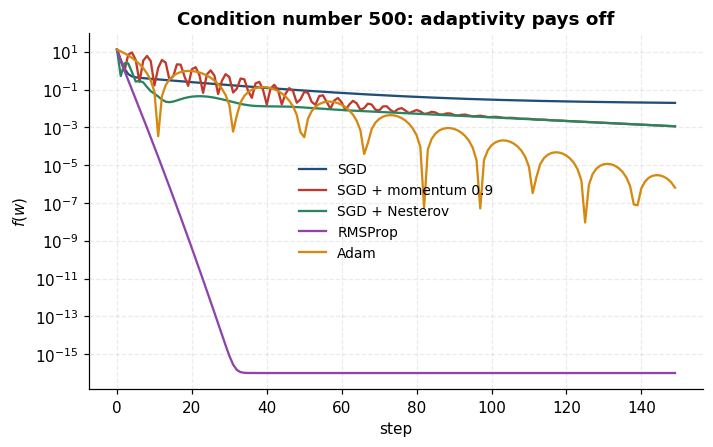

In [5]:
eigenvalues = np.array([25.0, 1.0, 0.05])
A = np.diag(eigenvalues)


def run(optimizer_cls, steps=150, **kwargs):
    w = Tensor(np.array([1.0, 1.0, 1.0]))
    opt = optimizer_cls([w], **kwargs)
    trace = []
    for _ in range(steps):
        opt.zero_grad()
        w.grad = A @ w.data
        trace.append(float(0.5 * w.data @ A @ w.data))
        opt.step()
    return np.asarray(trace)


fig, ax = plt.subplots(figsize=(7.2, 4.2))
for label, cls, kwargs in [
    ("SGD", SGD, dict(lr=0.02)),
    ("SGD + momentum 0.9", SGD, dict(lr=0.02, momentum=0.9)),
    ("SGD + Nesterov", SGD, dict(lr=0.02, momentum=0.9, nesterov=True)),
    ("RMSProp", RMSProp, dict(lr=0.05)),
    ("Adam", Adam, dict(lr=0.1)),
]:
    ax.plot(run(cls, **kwargs) + 1e-16, label=label)
ax.set_yscale("log")
ax.set_xlabel("step")
ax.set_ylabel(r"$f(w)$")
ax.set_title(f"Condition number {eigenvalues.max() / eigenvalues.min():.0f}: "
             "adaptivity pays off")
ax.legend(fontsize=9)
plt.show()

## 4. Warm-up and cosine decay

Large steps early in training are unstable (the loss surface near initialisation
is poorly conditioned); large steps late prevent settling. Linear warm-up
followed by cosine decay addresses both and has become the default schedule.

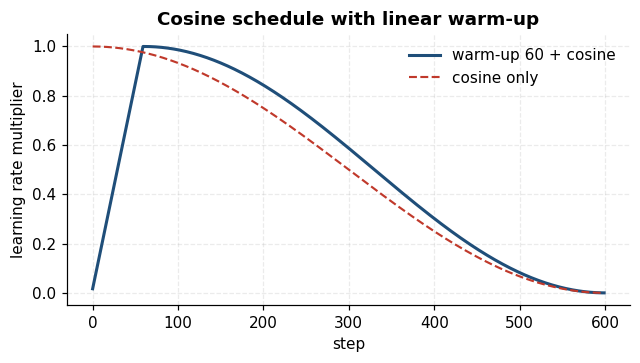

In [6]:
steps = np.arange(600)
fig, ax = plt.subplots(figsize=(6.6, 3.2))
ax.plot(steps, [cosine_with_warmup(s, 1.0, warmup_steps=60, total_steps=600) for s in steps],
        lw=2, label="warm-up 60 + cosine")
ax.plot(steps, [cosine_with_warmup(s, 1.0, warmup_steps=0, total_steps=600) for s in steps],
        lw=1.4, ls="--", label="cosine only")
ax.set_xlabel("step")
ax.set_ylabel("learning rate multiplier")
ax.set_title("Cosine schedule with linear warm-up")
ax.legend()
plt.show()

## 5. Putting it together: an MLP trained by our own engine

The `Linear` layers below stack on the same `Tensor` type, so the training loop
is the familiar `zero_grad -> backward -> step`. Nothing below calls a
framework.

parameter tensors: 6, scalars: 1185


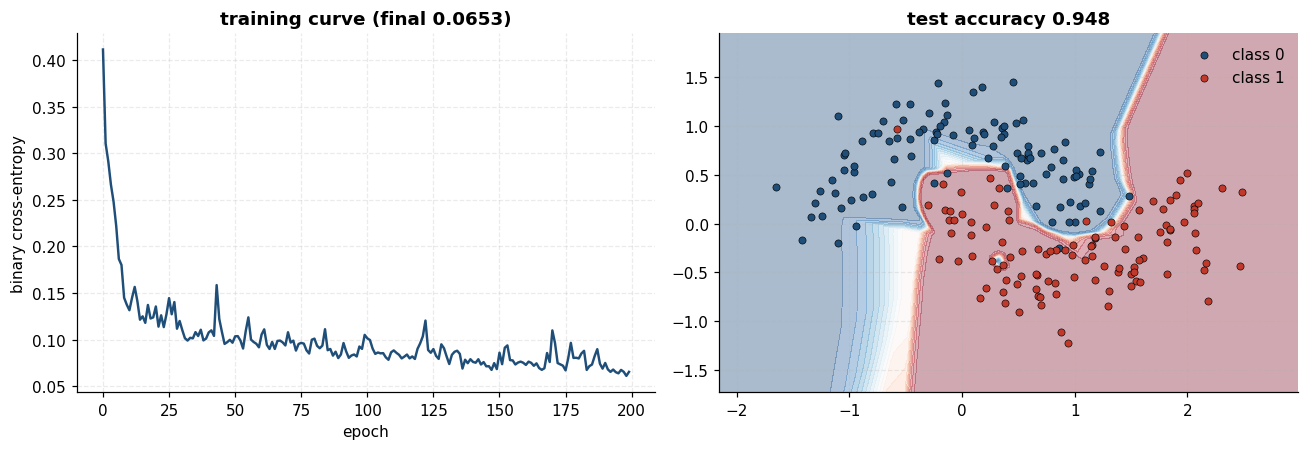

In [7]:
X, y = make_two_moons(700, noise=0.25, random_state=1)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

net = Sequential(Linear(2, 32, random_state=0), ReLU(),
                 Linear(32, 32, random_state=1), ReLU(),
                 Linear(32, 1, random_state=2))
print(f"parameter tensors: {len(net.parameters())}, "
      f"scalars: {sum(p.data.size for p in net.parameters())}")

clf = MLPClassifier(hidden=(32, 32), lr=0.02, epochs=200, batch_size=32,
                    optimizer=Adam, random_state=0).fit(X_tr, y_tr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(clf.loss_history_, lw=1.6)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("binary cross-entropy")
axes[0].set_title(f"training curve (final {clf.loss_history_[-1]:.4f})")
plot_decision_boundary(lambda g: clf.predict_proba(g)[:, 1], X_te, y_te, ax=axes[1],
                       levels=np.linspace(0, 1, 21),
                       title=f"test accuracy {accuracy(y_te, clf.predict(X_te)):.3f}")
plt.tight_layout()
plt.show()

## 6. Optimiser choice inside real training

The quadratic above is a caricature; here the same comparison runs on the actual
network. Adam and AdamW converge fastest per epoch, while momentum SGD needs a
larger step size to keep up -- one reason adaptive methods dominate defaults.

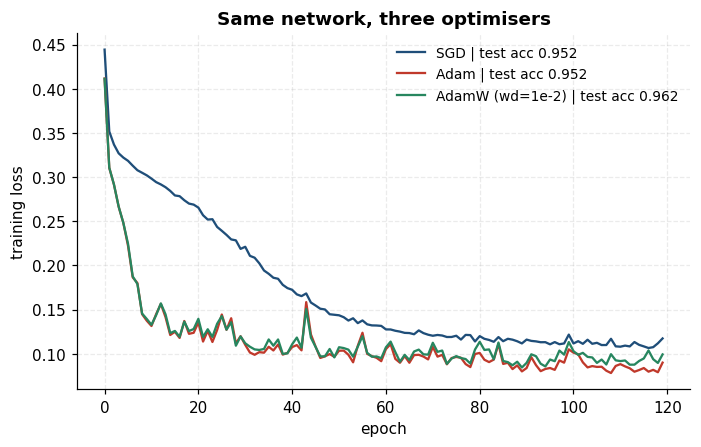

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
for label, cls, lr, wd in [("SGD", SGD, 0.1, 0.0),
                           ("Adam", Adam, 0.02, 0.0),
                           ("AdamW (wd=1e-2)", AdamW, 0.02, 1e-2)]:
    fit = MLPClassifier(hidden=(32, 32), lr=lr, epochs=120, batch_size=32,
                        optimizer=cls, weight_decay=wd, random_state=0).fit(X_tr, y_tr)
    ax.plot(fit.loss_history_,
            label=f"{label} | test acc {accuracy(y_te, fit.predict(X_te)):.3f}")
ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
ax.set_title("Same network, three optimisers")
ax.legend(fontsize=9)
plt.show()

## 7. Regression, and where a network beats a kernel

The same engine handles regression by swapping the loss. Compare the fit with
the kernel ridge model of notebook 03: similar accuracy here, but the network
scales linearly in $n$ while the kernel method needs an $n \times n$ matrix.

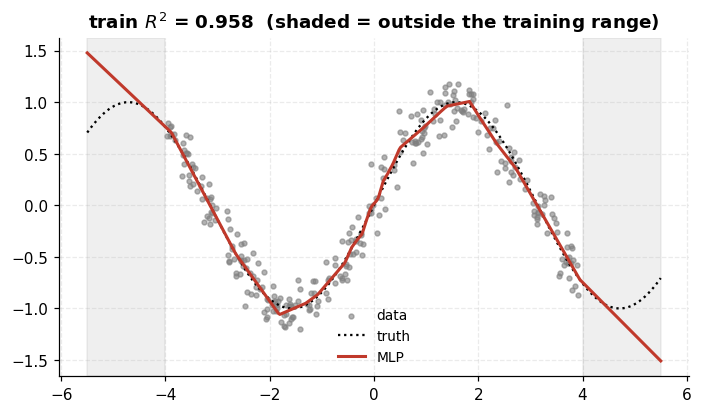

In [9]:
Xr, yr = make_sine(300, noise=0.15, x_range=(-4, 4), random_state=2)
reg = MLPRegressor(hidden=(48, 48), lr=0.01, epochs=250, batch_size=32,
                   schedule=cosine_with_warmup, random_state=0).fit(Xr, yr)

grid = np.linspace(-5.5, 5.5, 400).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(7.4, 4))
ax.scatter(Xr, yr, s=10, color="grey", alpha=0.6, label="data")
ax.plot(grid, np.sin(grid), "k:", label="truth")
ax.plot(grid, reg.predict(grid), lw=2, color=PALETTE[1], label="MLP")
ax.axvspan(-5.5, -4, color="grey", alpha=0.12)
ax.axvspan(4, 5.5, color="grey", alpha=0.12)
ax.set_title(f"train $R^2$ = {r2_score(yr, reg.predict(Xr)):.3f}"
             "  (shaded = outside the training range)")
ax.legend(fontsize=9)
plt.show()

Outside the training range the ReLU network extrapolates *linearly* and with no
warning -- contrast the GP in notebook 04, which widened its error bars instead.
Neither behaviour is a bug; it is the inductive bias of the model class.

## 8. What to take away

1. Reverse-mode AD costs one backward pass per scalar output, which is why it
   fits loss minimisation exactly.
2. Broadcasting must be undone in the backward pass -- the most common source of
   silent bugs, and the reason gradient checks are non-negotiable.
3. Momentum and per-coordinate scaling address ill-conditioning in different
   ways; Adam combines both and is a reasonable default.
4. Warm-up plus cosine decay stabilises early training and sharpens the end.
5. Networks extrapolate confidently and wrongly. Uncertainty must be added
   deliberately -- the subject of notebook 08.